<a id='start'></a>
# Reti neurali con Tensor Flow

In questo notebook vengono presentati degli esercizi sulle reti neurali con Tensor Flow.

Provate a svolgere il seguente esercizio:<br>
1) [pp -> H -> ZZ -> 4lepton](#section1)<br>

<a id='section1'></a>
## pp -> H -> ZZ -> 4lepton

Creare una rete neurale per analizzare i dati prodotti dagli studi di pp -> H -> ZZ -> 4lepton nel contesto delle ricerche mono-Higgs da parte della collaborazione CMS. I programmi usano le ntuple ridotte (con il nome dell'albero radice HZZ4LeptonsAnalysisReduced) create con Root.

In [2]:
import uproot
import pandas as pd
import numpy as np
import h5py

# fix random seed for reproducibility
seed = 7
np.random.seed(seed)

treename = 'HZZ4LeptonsAnalysisReduced'

VARS = ['f_mass4l', 'f_massjj']
upfile_VV = uproot.open('data/ntuple_4mu_VV.root')
params_VV = upfile_VV[treename].arrays(VARS, library="np")
upfile_BKG = uproot.open('data/ntuple_4mu_bkg.root')
params_BKG = upfile_BKG[treename].arrays(VARS, library="np")

df_VV = pd.DataFrame(params_VV, columns=VARS)
df_BKG = pd.DataFrame(params_BKG, columns=VARS)
    
# cut out undefined variables VARS[0] and VARS[1] > -999
df_VV = df_VV[(df_VV[VARS[0]] > -999) & (df_VV[VARS[1]] > -999)]
df_BKG = df_BKG[(df_BKG[VARS[0]] > -999) & (df_BKG[VARS[1]] > -999)] 

# add isSignal variable
df_VV['isSignal'] = np.ones(len(df_VV)) 
df_BKG['isSignal'] = np.zeros(len(df_BKG))

df_all = pd.concat([df_VV, df_BKG])
df_all

,f_mass4l,f_massjj,isSignal
0,125.077103,1300.426880,1.0
1,124.238113,437.221863,1.0
3,124.480667,1021.744080,1.0
4,124.919464,1101.381958,1.0
7,125.049065,498.717194,1.0
...,...,...,...
58056,197.383133,114.257278,0.0
58057,218.065582,106.195534,0.0
58060,89.288086,53.661579,0.0
58062,146.756577,71.162025,0.0


Creiamo una rete densa, con un singolo livello nascosto completamente connesso con lo stesso numero di neuroni delle variabili di input.

Possiamo quindi usare la funzione di attivazione `sigmoide` per produrre un'uscita di probabilità nell'intervallo da 0 a 1.

Infine usiamo la funzione di loss `binary_crossentropy` durante l'allenamento, una funzione di perdita standard per problemi di classificazione binaria.

Infine utimmizziamo il modello con l'algoritmo Adam per il grandient descend.

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, ReLU

NDIM = len(VARS)
model = Sequential()

model.add(Dense(2, input_dim=2))
model.add(ReLU())
model.add(Dense(units=2))
model.add(ReLU())
model.add(Dense(units=1, activation='sigmoid'))


model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# print the model summary
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 2)                 6         
_________________________________________________________________
re_lu (ReLU)                 (None, 2)                 0         
_________________________________________________________________
dense_1 (Dense)              (None, 2)                 6         
_________________________________________________________________
re_lu_1 (ReLU)               (None, 2)                 0         
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 3         
Total params: 15
Trainable params: 15
Non-trainable params: 0
_________________________________________________________________


In [4]:
X = df_all[VARS]
y = df_all['isSignal']
X

,f_mass4l,f_massjj
0,125.077103,1300.426880
1,124.238113,437.221863
3,124.480667,1021.744080
4,124.919464,1101.381958
7,125.049065,498.717194
...,...,...
58056,197.383133,114.257278
58057,218.065582,106.195534
58060,89.288086,53.661579
58062,146.756577,71.162025


Procediamo a questo punto a suddividere i dati tra input e test e a effettuare uno scaling:

In [5]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# preprocessing: standard scalar
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(x_train)
X_train_val = scaler.transform(x_train)
X_test_val = scaler.transform(x_test)

Ora facciamo il training:

In [6]:
# early stopping callback
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10)

history = model.fit(X_train_val,
                    y_train,
                    epochs=1000, 
                    verbose=1, # switch to 0 for less verbosity 
                    callbacks=[early_stopping], 
                    validation_data=(X_test_val, y_test))

Epoch 1/1000
519/519 [==============================] - 1s 1ms/step - loss: 0.6476 - accuracy: 0.6902 - val_loss: 0.6061 - val_accuracy: 0.7517
Epoch 2/1000
519/519 [==============================] - 1s 975us/step - loss: 0.5830 - accuracy: 0.7561 - val_loss: 0.5704 - val_accuracy: 0.7517
Epoch 3/1000
519/519 [==============================] - 0s 952us/step - loss: 0.5593 - accuracy: 0.7561 - val_loss: 0.5566 - val_accuracy: 0.7517
Epoch 4/1000
519/519 [==============================] - 0s 951us/step - loss: 0.5491 - accuracy: 0.7561 - val_loss: 0.5488 - val_accuracy: 0.7517
Epoch 5/1000
519/519 [==============================] - 1s 1ms/step - loss: 0.5419 - accuracy: 0.7567 - val_loss: 0.5418 - val_accuracy: 0.7539
Epoch 6/1000
519/519 [==============================] - 0s 936us/step - loss: 0.5355 - accuracy: 0.7740 - val_loss: 0.5354 - val_accuracy: 0.7794
Epoch 7/1000
519/519 [==============================] - 1s 1ms/step - loss: 0.5311 - accuracy: 0.7807 - val_loss: 0.5319 - val_a

519/519 [==============================] - 1s 966us/step - loss: 0.5235 - accuracy: 0.7813 - val_loss: 0.5244 - val_accuracy: 0.7799
Epoch 58/1000
519/519 [==============================] - 0s 928us/step - loss: 0.5235 - accuracy: 0.7812 - val_loss: 0.5246 - val_accuracy: 0.7799
Epoch 59/1000
519/519 [==============================] - 1s 1ms/step - loss: 0.5235 - accuracy: 0.7812 - val_loss: 0.5245 - val_accuracy: 0.7799
Epoch 60/1000
519/519 [==============================] - 1s 1ms/step - loss: 0.5234 - accuracy: 0.7815 - val_loss: 0.5243 - val_accuracy: 0.7799
Epoch 61/1000
519/519 [==============================] - 0s 927us/step - loss: 0.5235 - accuracy: 0.7811 - val_loss: 0.5244 - val_accuracy: 0.7797
Epoch 62/1000
519/519 [==============================] - 0s 920us/step - loss: 0.5234 - accuracy: 0.7812 - val_loss: 0.5243 - val_accuracy: 0.7799
Epoch 63/1000
519/519 [==============================] - 0s 939us/step - loss: 0.5235 - accuracy: 0.7812 - val_loss: 0.5244 - val_accura

Stampiamo loss e accuracy:

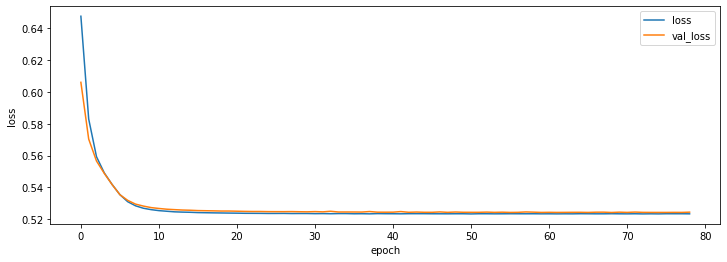

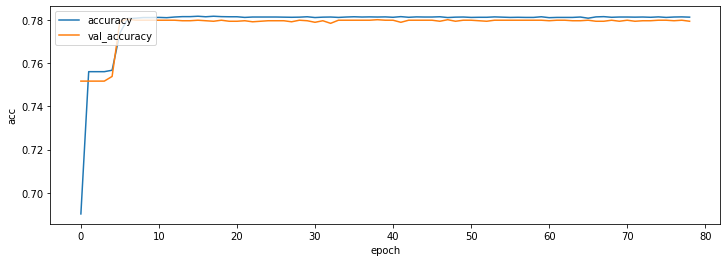

In [7]:
import matplotlib.pyplot as plt

# plot loss vs epoch
plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(loc="upper right")
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

# plot accuracy vs epoch
plt.figure(figsize=(12, 4))
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend(loc="upper left")
plt.xlabel('epoch')
plt.ylabel('acc')
plt.show()

Vediamo il modello in azione:

In [8]:
X_val = scaler.transform(X)
df_all['predict'] = model.predict(X_val)

df_all['predict'] = np.around(df_all['predict']).astype(np.int64)
df_all['isSignal'] = np.around(df_all['isSignal']).astype(np.int64)

df_all

,f_mass4l,f_massjj,isSignal,predict
0,125.077103,1300.426880,1,1
1,124.238113,437.221863,1,1
3,124.480667,1021.744080,1,1
4,124.919464,1101.381958,1,1
7,125.049065,498.717194,1,1
...,...,...,...,...
58056,197.383133,114.257278,0,1
58057,218.065582,106.195534,0,1
58060,89.288086,53.661579,0,0
58062,146.756577,71.162025,0,1


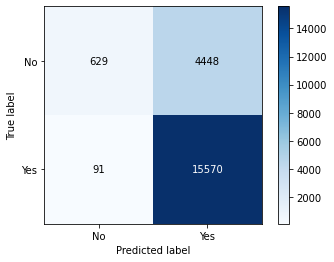

In [9]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(df_all['isSignal'].array, df_all['predict'].array)
classes = ['No', 'Yes']

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap=plt.cm.Blues)

ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=classes,
       yticklabels=classes,
       ylabel='True label',
       xlabel='Predicted label')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2. else "black")

In [10]:
right = df_all.loc[df_all['predict'] == df_all['isSignal']]
wrong = df_all.loc[df_all['predict'] != df_all['isSignal']]

true_positive = right.loc[right['predict'] == 1]
false_positive = wrong.loc[wrong['predict'] == 1]
false_negative = wrong.loc[wrong['predict'] == 0]

print("We had %d elements in our recordset." % len(df_all))
print("We classified correctly %d events." % len(right))
print("We classified wrongly %d events." % len(wrong))
print("We had %d false positive and %d false negative." % (len(false_positive), len(false_negative)))

print("")

print("Our precision has been %1.2f." % (len(true_positive)/(len(true_positive) + len(false_positive))))
print("Our recall has been %1.2f." % (len(true_positive)/(len(true_positive) + len(false_negative))))

We had 20738 elements in our recordset.
We classified correctly 16199 events.
We classified wrongly 4539 events.
We had 4448 false positive and 91 false negative.

Our precision has been 0.78.
Our recall has been 0.99.


<img src="img/Precisionrecall.png" width="300"/>

[Clicca qui per tornare all'inizio della pagina](#start)<a id='start'></a>